# Segunda fase

In [2]:
import pandas

# Importing classes of the project

# Reload classes in memory every time this code block is executed
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import torch
from sklearn.metrics import classification_report
from sklearn.utils import compute_class_weight
from collections import Counter
from imblearn.over_sampling import SMOTE
from matplotlib import pyplot as plt
from data_analysis.analizer import DataAnalizer

from model_building.KNN import KNN
from model_building.DecisionTree import DecisionTree
from model_building.SVM import SupportVectorMachine
from model_building.ModelEvaluator import ModelEvaluator
from model_building.BaseNeuralNetwork import BaseNeuralNetwork
from model_building.NeuralNetworkTrainer import NeuralNetworkTrainer


In [3]:
# ==========================================
#  Setup do diretório de output dos modelos
# ==========================================
model_output_dir = "../out/models/"
os.makedirs(model_output_dir, exist_ok=True)


# ==================
#  Setup do dataset
# ==================

df = pd.read_csv("../out/dataset.csv")

# a grande maioria das entradas têm valores nulos em "congestion_surcharge"
del df["congestion_surcharge"]

# dados continuos (não é possivel normalizar estes dados)
del df["pickup_time_in_seconds"]
del df["dropoff_time_in_seconds"]

# Remove all rows with any missing values (NaN)
df= df.dropna()
df

,trip_distance,fare_amount,tip_amount,tolls_amount,extra,passenger_count,pickup_hour,pickup_day_of_week,pickup_day_of_month,pickup_month,dropoff_hour,dropoff_day_of_week,dropoff_day_of_month,dropoff_month,mta_tax,vendorid,ratecodeid,pulocationid,dolocationid,payment_type
0,0.90,9.5,0.00,0.0,0.5,4.0,0,1,1,1,0,1,1,1,0.5,1.0,1.0,68.0,246.0,2.0
1,1.29,6.5,1.56,0.0,0.5,2.0,0,1,1,1,0,1,1,1,0.5,2.0,1.0,231.0,87.0,1.0
2,4.70,15.5,0.00,0.0,0.5,0.0,0,1,1,1,0,1,1,1,0.5,1.0,1.0,233.0,74.0,2.0
3,3.74,12.5,0.00,0.0,0.5,1.0,0,1,1,1,0,1,1,1,0.5,2.0,1.0,142.0,75.0,2.0
4,1.72,7.0,2.08,0.0,0.5,1.0,0,1,1,1,0,1,1,1,0.5,2.0,1.0,229.0,263.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83985,4.54,18.0,2.00,0.0,0.5,3.0,23,1,31,12,23,1,31,12,0.5,2.0,1.0,87.0,48.0,1.0
83986,1.27,6.5,2.06,0.0,0.5,4.0,23,1,31,12,23,1,31,12,0.5,2.0,1.0,231.0,144.0,1.0
83987,0.77,5.0,0.88,0.0,0.5,1.0,22,1,31,12,23,1,31,12,0.5,2.0,1.0,236.0,43.0,1.0
83988,0.40,3.5,1.46,0.0,0.5,1.0,23,1,31,12,23,1,31,12,0.5,2.0,1.0,68.0,186.0,1.0


In [4]:
# =============================================
# 1. REGRESSION DATASET (continuous target)
# =============================================

# Separate features and target
X_reg = df.drop(columns=['fare_amount'])
y_reg = df['fare_amount']

# Scale only the features (not target)
scaler = StandardScaler()
X_reg_scaled = scaler.fit_transform(X_reg)

# Create scaled DataFrame for regression
df_regression = pd.DataFrame(X_reg_scaled, columns=X_reg.columns)
df_regression['fare_amount'] = y_reg.values  # Add unscaled target

# =============================================
# 2. CLASSIFICATION DATASET (categorical target)
# =============================================

# Create fare classes
bins = [-np.inf, 10, 30, 60, np.inf]
labels = [1, 2, 3, 4]

# Create classification target
df_classification = df.copy()
df_classification['fare_class'] = pd.cut(
    df['fare_amount'],
    bins=bins,
    labels=labels
)

# Separate features and target
X_clf = df_classification.drop(columns=['fare_amount', 'fare_class'])
y_clf = df_classification['fare_class']

# Scale features using SAME scaler (important for consistency)
X_clf_scaled = scaler.transform(X_clf)  # Use existing scaler

# Create scaled DataFrame for classification
df_classification_scaled = pd.DataFrame(X_clf_scaled, columns=X_clf.columns)
df_classification_scaled['fare_class'] = y_clf.values  # Add target

analizer_reg = DataAnalizer(df_regression, "fare_amount", test_size=0.02)

# =============================================
# Verification
# =============================================
print("Regression dataset:")
print(df_regression.head())

print("\nClassification dataset:")
print(df_classification_scaled.head())

print(df_classification['fare_class'].value_counts(normalize=True))

analizer_clf = DataAnalizer(df_classification_scaled, "fare_class", test_size=0.2)

Data divided successfully.
Regression dataset:
   trip_distance  tip_amount  tolls_amount     extra  passenger_count  \
0      -0.538521   -0.794049     -0.232633 -0.463892         2.000561   
1      -0.438387   -0.231552     -0.232633 -0.463892         0.354915   
2       0.437149   -0.794049     -0.232633 -0.463892        -1.290731   
3       0.190664   -0.794049     -0.232633 -0.463892        -0.467908   
4      -0.327982   -0.044053     -0.232633 -0.463892        -0.467908   

   pickup_hour  pickup_day_of_week  pickup_day_of_month  pickup_month  \
0    -2.320657           -1.022567            -1.670152     -1.533741   
1    -2.320657           -1.022567            -1.670152     -1.533741   
2    -2.320657           -1.022567            -1.670152     -1.533741   
3    -2.320657           -1.022567            -1.670152     -1.533741   
4    -2.320657           -1.022567            -1.670152     -1.533741   

   dropoff_hour  dropoff_day_of_week  dropoff_day_of_month  dropoff_month  

# KNN

O KNN (K-Nearest Neighbors, ou K-Vizinhos Mais Próximos) é um algoritmo de aprendizado de máquina supervisionado usado para classificação e regressão. Ele se baseia no princípio de que objetos semelhantes estão próximos no espaço de características.

**Funcionamento:**


Calcula a distância (ex.: Euclidiana, Manhattan) entre o novo dado e todos os pontos no conjunto de treinamento.

Seleciona os K vizinhos mais próximos.

Classifica (moda das classes dos vizinhos) ou prediz (média dos valores dos vizinhos).



In [26]:
# Regression Analysis of KNN
rmse_results = {}
for i in range(2, 26, 5):
    print(f"Training KNN Regression for k = {i}")
    knn_reg = KNN(i, task="regression", verbose=True)
    knn_reg.fit(analizer_reg.data_train, analizer_reg.labels_train)
    pred_values = knn_reg.predict(analizer_reg.data_test)

    # Calculate Root Mean Squared Error
    rmse = np.sqrt(np.mean((pred_values - analizer_reg.labels_test)**2))
    rmse_results[i] = rmse
    print(f"k={i}: RMSE = {rmse:.2f}")

print("\nFinal Regression Results:")
print(rmse_results)

Data divided successfully.
Training KNN Regression for k = 5
KD-Tree built with 131068 nodes, dimensions=19
Processed 1000/1688
Prediction complete
k=5: RMSE = 4.43
Training KNN Regression for k = 10
KD-Tree built with 131068 nodes, dimensions=19
Processed 1000/1688
Prediction complete
k=10: RMSE = 4.63
Training KNN Regression for k = 15
KD-Tree built with 131068 nodes, dimensions=19
Processed 1000/1688
Prediction complete
k=15: RMSE = 4.80
Training KNN Regression for k = 20
KD-Tree built with 131068 nodes, dimensions=19
Processed 1000/1688
Prediction complete
k=20: RMSE = 4.90
Training KNN Regression for k = 25
KD-Tree built with 131068 nodes, dimensions=19
Processed 1000/1688
Prediction complete
k=25: RMSE = 4.99

Final Regression Results:
{5: np.float64(4.427841938487359), 10: np.float64(4.626283588500842), 15: np.float64(4.79722290519828), 20: np.float64(4.8972478527938845), 25: np.float64(4.990911051727522)}


In [ ]:
# Classification Analysis of KNN
precision_results = {}
for i in range(5, 26, 5):
    print(f"Training KNN Classification for k = {i}")
    knn_clf = KNN(i, task="classification", verbose=True)
    knn_clf.fit(analizer_clf.data_train, analizer_clf.labels_train)
    pred_labels = knn_clf.predict(analizer_clf.data_test)

    # Calculate Precision (accuracy)
    precision = np.mean(pred_labels == analizer_clf.labels_test)
    precision_results[i] = precision
    print(f"k={i}: Precision = {precision:.4f}")

print("\nFinal Classification Results:")
print(precision_results)

Data divided successfully.
Training KNN Classification for k = 5
KD-Tree built with 131008 nodes, dimensions=19
Processed 1000/16876
Processed 2000/16876
Processed 3000/16876
Processed 4000/16876
Processed 5000/16876
Processed 6000/16876
Processed 7000/16876
Processed 8000/16876
Processed 9000/16876
Processed 10000/16876
Processed 11000/16876
Processed 12000/16876
Processed 13000/16876
Processed 14000/16876
Processed 15000/16876
Processed 16000/16876
Prediction complete
k=5: Precision = 0.7533
Training KNN Classification for k = 10
KD-Tree built with 131008 nodes, dimensions=19
Processed 1000/16876
Processed 2000/16876
Processed 3000/16876
Processed 4000/16876
Processed 5000/16876
Processed 6000/16876
Processed 7000/16876
Processed 8000/16876
Processed 9000/16876
Processed 10000/16876
Processed 11000/16876
Processed 12000/16876
Processed 13000/16876
Processed 14000/16876
Processed 15000/16876
Processed 16000/16876
Prediction complete
k=10: Precision = 0.7489
Training KNN Classification

# Árvore de decisão

A Árvore de Decisão é um algoritmo de aprendizado de máquina supervisionado usado para classificação e regressão. Ele divide os dados em subconjuntos com base em regras de decisão hierárquicas, formando uma estrutura semelhante a uma árvore.

**Funcionamento:**

Seleciona o melhor atributo para dividir os dados (usando critérios como Gini, Entropia ou Erro quadrático).

Divide o dataset recursivamente, criando nós de decisão até atingir uma condição de parada (ex.: profundidade máxima ou número mínimo de amostras por folha).

Classifica ou prediz com base na folha (nó final) em que o dado cai.

In [48]:
# Classification with Decision Tree
best_f1_macro = -float('inf') # Inicializa com um valor muito baixo para encontrar o máximo
best_model_clf = None
best_depth_clf = None
all_clf_results = {} # Opcional: para armazenar todos os resultados se necessário

print("--- Classificação com Decision Tree ---")

for depth in [None, 2, 5, 10, 20]:
    print(f"\nTraining Decision Tree Classification for max_depth = {depth}")
    dt_clf = DecisionTree(
        problem_type='classification',
        max_depth=depth,
        class_weight='balanced',
        random_state=42 # Adicionado para reprodutibilidade se a árvore tiver elementos aleatórios
    )

    # evaluate the model
    evaluator = ModelEvaluator(
        model=dt_clf,
        task_type="multiclass",
        metrics=["accuracy", "precision_macro", "recall_macro", "f1_macro", "log_loss"],
        cv_method='stratifiedkfold',
        cv_folds=5,
        random_state=42 # Adicionado para reprodutibilidade na CV
    )

    print(f"max_depth={depth}")
    try:
        results_clf = evaluator.evaluate(analizer_clf.data_train, analizer_clf.labels_train)
        all_clf_results[depth] = results_clf # Armazena os resultados

        print("Resultados CV:")
        for metric, value in results_clf.items():
             # Verifica se é um valor numérico para formatar
            if isinstance(value, (int, float)):
                 print(f"{metric}: {value:.4f}")
            else:
                 print(f"{metric}: {value}")


        # --- Lógica para selecionar o melhor modelo ---
        # Usamos a média do f1_macro da validação cruzada para comparar
        current_f1_macro_mean = results_clf.get('f1_macro_mean') # Assume que ModelEvaluator retorna metric_mean

        if current_f1_macro_mean is not None and current_f1_macro_mean > best_f1_macro:
            best_f1_macro = current_f1_macro_mean
            best_model_clf = dt_clf # Guarda a instância do modelo treinado no último fold ou a regra da classe ModelEvaluator
            best_depth_clf = depth
            print(f"-> Novo melhor modelo encontrado com max_depth={depth} (f1_macro_mean={best_f1_macro:.4f})")

    except Exception as e:
        print(f"An error occurred during evaluation for max_depth={depth}: {e}")

if best_model_clf is not None:
    print("-" * 30)
    print("Saving best model...")
    best_model_clf.serialize(model_output_dir+"decisionTreeClassfier.pkl")
    print("-" * 30)

--- Classificação com Decision Tree ---

Training Decision Tree Classification for max_depth = None
max_depth=None
Resultados CV:
accuracy_mean: 0.8894
precision_macro_mean: 0.8535
recall_macro_mean: 0.8461
f1_macro_mean: 0.8496
log_loss_mean: 3.9866
accuracy_std: 0.0030
precision_macro_std: 0.0060
recall_macro_std: 0.0106
f1_macro_std: 0.0060
log_loss_std: 0.1067
-> Novo melhor modelo encontrado com max_depth=None (f1_macro_mean=0.8496)

Training Decision Tree Classification for max_depth = 2
max_depth=2
Resultados CV:
accuracy_mean: 0.7698
precision_macro_mean: 0.6634
recall_macro_mean: 0.7161
f1_macro_mean: 0.6775
log_loss_mean: 0.6784
accuracy_std: 0.1183
precision_macro_std: 0.1633
recall_macro_std: 0.0514
f1_macro_std: 0.1120
log_loss_std: 0.0812

Training Decision Tree Classification for max_depth = 5
max_depth=5
Resultados CV:
accuracy_mean: 0.8623
precision_macro_mean: 0.7739
recall_macro_mean: 0.8834
f1_macro_mean: 0.8189
log_loss_mean: 0.3529
accuracy_std: 0.0033
precision_m

In [49]:
best_rmse = float('inf') # Initialize with a very high value to find the minimum
best_model_reg = None
best_depth_reg = None
all_reg_results = {} # Opcional: para armazenar todos os resultados se necessário

print("\n" + "=" * 40) # Separator
print("--- Regressão com Decision Tree ---")

for depth in [None, 2, 5, 10, 20]:
    print(f"\nTraining Decision Tree Regression for max_depth = {depth}")
    dt_reg = DecisionTree(problem_type='regression', max_depth=depth, random_state=42)

    # Evaluate the model using ModelEvaluator for regression with multiple metrics
    evaluator_reg = ModelEvaluator(
        model=dt_reg,
        task_type="regression",
        metrics=['rmse', 'mse', 'mae', 'r2'],  # Evaluate using RMSE, MSE, MAE, and R-squared
        cv_method='kfold',
        cv_folds=5,
        random_state=42
    )

    print(f"max_depth={depth}")
    try:
        results_reg = evaluator_reg.evaluate(analizer_reg.data_train, analizer_reg.labels_train)
        all_reg_results[depth] = results_reg # Armazena os resultados

        print("Resultados CV:")
        # Extract and print mean/std for key metrics for the current depth
        current_rmse_mean = results_reg.get('rmse_mean')
        current_mse_mean = results_reg.get('mse_mean')
        current_mae_mean = results_reg.get('mae_mean')
        current_r2_mean = results_reg.get('r2_mean')

        if current_rmse_mean is not None: print(f"rmse_mean: {current_rmse_mean:.4f}")
        if results_reg.get('rmse_std') is not None: print(f"rmse_std: {results_reg['rmse_std']:.4f}")
        if current_mse_mean is not None: print(f"mse_mean: {current_mse_mean:.4f}")
        if results_reg.get('mse_std') is not None: print(f"mse_std: {results_reg['mse_std']:.4f}")
        if current_mae_mean is not None: print(f"mae_mean: {current_mae_mean:.4f}")
        if results_reg.get('mae_std') is not None: print(f"mae_std: {results_reg['mae_std']:.4f}")
        if current_r2_mean is not None: print(f"r2_mean: {current_r2_mean:.4f}")
        if results_reg.get('r2_std') is not None: print(f"r2_std: {results_reg['r2_std']:.4f}")


        # --- Lógica para selecionar o melhor modelo de REGRESSÃO ---
        # Usamos a média do rmse da validação cruzada para comparar (menor é melhor)
        # current_rmse_mean is already extracted above

        if current_rmse_mean is not None and current_rmse_mean < best_rmse:
            best_rmse = current_rmse_mean
            best_model_reg = dt_reg # Guarda a instância do modelo configurado para esta profundidade
            best_depth_reg = depth
            print(f"-> Novo melhor modelo REGRESSÃO encontrado com max_depth={depth} (rmse_mean={best_rmse:.4f})")

    except Exception as e:
        print(f"An error occurred during regression evaluation for max_depth={depth}: {e}")

# --- Salva o melhor modelo de REGRESSÃO ---
if best_model_reg is not None:
    print("-" * 30)
    print("Saving best regression model...")
     # Similar note as classification: re-train on full data if needed before saving
    best_model_reg.serialize(model_output_dir+"decisionTreeRegressor.pkl")
    print(f"Best regression model (max_depth={best_depth_reg}, rmse_mean={best_rmse:.4f}) saved to {model_output_dir}decisionTreeRegressor.pkl")
    print("-" * 30)
else:
     print("-" * 30)
     print("No regression model was successfully evaluated.")
     print("-" * 30)


--- Regressão com Decision Tree ---

Training Decision Tree Regression for max_depth = None
max_depth=None
Resultados CV:
rmse_mean: 6.1539
rmse_std: 1.7570
mse_mean: 40.9578
mse_std: 22.8139
mae_mean: 1.7001
mae_std: 0.0219
r2_mean: 0.7480
r2_std: 0.1206
-> Novo melhor modelo REGRESSÃO encontrado com max_depth=None (rmse_mean=6.1539)

Training Decision Tree Regression for max_depth = 2
max_depth=2
Resultados CV:
rmse_mean: 7.2412
rmse_std: 1.0688
mse_mean: 53.5772
mse_std: 16.8143
mae_mean: 3.2621
mae_std: 0.0271
r2_mean: 0.6639
r2_std: 0.0668

Training Decision Tree Regression for max_depth = 5
max_depth=5
Resultados CV:
rmse_mean: 6.1021
rmse_std: 1.7371
mse_mean: 40.2528
mse_std: 22.4762
mae_mean: 2.0160
mae_std: 0.0392
r2_mean: 0.7519
r2_std: 0.1213
-> Novo melhor modelo REGRESSÃO encontrado com max_depth=5 (rmse_mean=6.1021)

Training Decision Tree Regression for max_depth = 10
max_depth=10
Resultados CV:
rmse_mean: 5.0942
rmse_std: 1.4772
mse_mean: 28.1332
mse_std: 18.3094
mae_

# Support Vector Machine (SVM)

O SVM (Máquina de Vetores de Suporte) é um algoritmo de aprendizado de máquina supervisionado usado para classificação e regressão. Ele busca encontrar o hiperplano ótimo que melhor separa diferentes classes no espaço de características, maximizando a margem entre os pontos mais próximos (vetores de suporte).

**Funcionamento:**

Mapeia os dados para um espaço de maior dimensão** (usando kernels como linear, polinomial ou RBF, se necessário).

Encontra o hiperplano com a maior margem de separação entre classes.

Classifica novos dados com base em qual lado do hiperplano eles estão.

In [ ]:
# Regression with SVM
regression_results_cv_svm = {}
# Iterating over the regularization parameter C for Regression (SVR)
C_values_reg = [0.01, 0.1, 1, 10, 100] # Exemplo de valores de C para testar

for C_param in C_values_reg:
    print(f"Training Support Vector Machine Regression for C = {C_param}")

    # Instantiate the SVM Regression model (SVR)
    # Using default kernel (often 'rbf') unless specified
    # Note: SVR also has an 'epsilon' parameter (tolerance margin) which is often tuned
    svm_reg = SupportVectorMachine(
        problem_type='regression',
        C=C_param,
        kernel='linear', # Exemplo: usando kernel RBF
        # epsilon=0.1, # Pode adicionar e/ou iterar sobre epsilon também
        random_state=42 # Incluído por consistência
    )

    # Evaluate the model using ModelEvaluator for regression with multiple metrics
    evaluator_reg_svm = ModelEvaluator(
        model=svm_reg,
        task_type="regression",
        metrics=['rmse', 'mse', 'mae', 'r2'],  # Métricas adequadas para regressão
        cv_method='kfold', # Adequado para regressão
        cv_folds=5,
        random_state=42 # Adicionado para reprodutibilidade na CV
    )

    print(f"=== Regressão (Support Vector Machine) ===")
    print(f"C={C_param}")

    try:
        results_reg_svm = evaluator_reg_svm.evaluate(analizer_reg.data_train, analizer_reg.labels_train)

        # Store results - ensure metric names match what evaluator returns (e.g., 'rmse_mean')
        regression_results_cv_svm[C_param] = {
            'rmse_mean': results_reg_svm.get('rmse_mean'),
            'rmse_std': results_reg_svm.get('rmse_std'),
            'mse_mean': results_reg_svm.get('mse_mean'),
            'mse_std': results_reg_svm.get('mse_std'),
            'mae_mean': results_reg_svm.get('mae_mean'),
            'mae_std': results_reg_svm.get('mae_std'),
            'r2_mean': results_reg_svm.get('r2_mean'),
            'r2_std': results_reg_svm.get('r2_std')
        }

        for metric, value in regression_results_cv_svm[C_param].items():
            if value is not None:
                print(f"{metric}: {value:.4f}") # Ajustado para 4 casas decimais para consistência
    except Exception as e:
         print(f"An error occurred during evaluation for C={C_param}: {e}")


    print("-" * 30)

print("\nFinal Regression Results (Support Vector Machine Cross-Validation):")
print(regression_results_cv_svm)

In [12]:
# Classification with SVM

print(f"Training Support Vector Machine Classification")

svm_clf = SupportVectorMachine(
    problem_type='classification',
    kernel='linear', # Exemplo: usando kernel RBF. Outras opções: 'linear', 'poly', 'sigmoid'
    class_weight='balanced',
)

# evaluate the model
# Removed log_loss as standard SVC doesn't provide probabilities directly
evaluator_clf_svm = ModelEvaluator(
    model=svm_clf,
    task_type="multiclass",
    metrics=["accuracy", "precision_macro", "recall_macro", "f1_macro"], # Métricas adequadas para classificação
    cv_method='stratifiedkfold', # Adequado para classificação
    cv_folds=5,
    random_state=42 # Adicionado para reprodutibilidade na CV
)

print(f"=== Classificação (Support Vector Machine) ===")
try:
    results_clf_svm = evaluator_clf_svm.evaluate(analizer_clf.data_train, analizer_clf.labels_train)
    for metric, value in results_clf_svm.items():
        print(f"{metric}: {value:.4f}" if isinstance(value, float) else f"{metric}: {value}")
except Exception as e:
    print(f"An error occurred during evaluation: {e}")

print("-" * 30)



Training Support Vector Machine Classification
=== Classificação (Support Vector Machine) ===
An error occurred during evaluation: A worker process managed by the executor was unexpectedly terminated. This could be caused by a segmentation fault while calling the function or by an excessive memory usage causing the Operating System to kill the worker.

------------------------------


# Neural Networks

Vamos fazer Neural Networks para classificação e regressão. É de se notar que esta rede neuronal tem 3 camadas com 100 de epochs e um learning rate de 0.001.


In [11]:
#Classificação com Neural Networks
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(analizer_clf.data_train, analizer_clf.labels_train)

print("Class distribution after SMOTE:", Counter(y_resampled))

# Convert to tensors again
X_clf_train_t = torch.tensor(X_resampled.values, dtype=torch.float32)
y_clf_train_t = torch.tensor(y_resampled.values.astype(int) - 1, dtype=torch.long)

X_clf_test_t = torch.tensor(analizer_clf.data_test.values, dtype=torch.float32)
y_clf_test_t = torch.tensor(analizer_clf.labels_test.values.astype(int) - 1, dtype=torch.long)

y_train_np = analizer_clf.labels_train.values.astype(int) - 1
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_np), y=y_train_np)
weights[2] = weights[2] * 1.5  # Double the weight for class 2
weights[1] = weights[1] * 1.5
print("Modified class weights:", weights)
class_weights_tensor = torch.tensor(weights, dtype=torch.float32)

# Model
clf_model = BaseNeuralNetwork(input_dim=X_clf_train_t.shape[1], output_dim=4, task_type='classification')
clf_trainer = NeuralNetworkTrainer(clf_model, task='classification', class_weights=class_weights_tensor)
# Train
clf_trainer.train(X_clf_train_t, y_clf_train_t, epochs=100)

with torch.no_grad():
    outputs = clf_model(X_clf_test_t)
    _, predicted = torch.max(outputs, 1)

    # Check how many samples of each class are in the test set
    test_class_counts = Counter(y_clf_test_t.numpy())
    print("Test set class distribution:", test_class_counts)

    # Check how many samples of each class are predicted
    pred_class_counts = Counter(predicted.numpy())
    print("Predicted class distribution:", pred_class_counts)

    # Calculate accuracy for each class
    for cls in range(4):
        cls_indices = (y_clf_test_t == cls).nonzero(as_tuple=True)[0]
        if len(cls_indices) > 0:
            cls_correct = (predicted[cls_indices] == cls).sum().item()
            cls_accuracy = cls_correct / len(cls_indices)
            print(f"Class {cls} accuracy: {cls_accuracy:.4f} ({cls_correct}/{len(cls_indices)})")


Class distribution after SMOTE: Counter({2: 37198, 1: 37198, 3: 37198, 4: 37198})
Modified class weights: [ 0.45056858  1.01919062  5.29828767 38.88689095]
Epoch 0 - Loss: 0.8783
Epoch 10 - Loss: 0.7500
Epoch 20 - Loss: 0.7494
Epoch 30 - Loss: 0.7486
Epoch 40 - Loss: 0.7479
Epoch 50 - Loss: 0.7450
Epoch 60 - Loss: 0.7742
Epoch 70 - Loss: 0.8017
Epoch 80 - Loss: 0.7581
Epoch 90 - Loss: 0.7529
Test set class distribution: Counter({0: 9223, 1: 6218, 2: 1207, 3: 113})
Predicted class distribution: Counter({0: 5905, 1: 4931, 2: 3497, 3: 2428})
Class 0 accuracy: 0.6105 (5631/9223)
Class 1 accuracy: 0.5130 (3190/6218)
Class 2 accuracy: 0.9453 (1141/1207)
Class 3 accuracy: 0.8938 (101/113)



=== Classification Report ===
              precision    recall  f1-score   support

           0       0.94      0.83      0.88      9223
           1       0.76      0.81      0.78      6218
           2       0.61      0.95      0.74      1207
           3       0.54      0.92      0.68       113

    accuracy                           0.83     16761
   macro avg       0.71      0.88      0.77     16761
weighted avg       0.85      0.83      0.83     16761

Predicted classes: (tensor([0, 1, 2, 3]), tensor([8119, 6575, 1873,  194]))
Actual classes: tensor([0, 1, 2, 3])


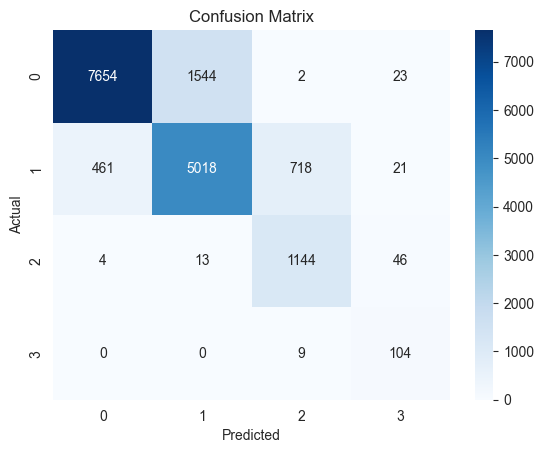

In [12]:
#Avaliação da rede para classificação
clf_trainer.evaluate(X_clf_test_t, y_clf_test_t)
y_pred_clf = clf_trainer.predict(X_clf_test_t)
print("Predicted classes:", torch.unique(y_pred_clf, return_counts=True))
print("Actual classes:", torch.unique(y_clf_test_t))

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_clf_test_t.numpy(), y_pred_clf.numpy())
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [15]:
#Regressão com Neural Network
X_reg_train = analizer_reg.data_train
y_reg_train = analizer_reg.labels_train

# Convert to tensors with proper shapes
X_reg_train_t = torch.tensor(X_reg_train.values, dtype=torch.float32)
y_reg_train_t = torch.tensor(y_reg_train.values, dtype=torch.float32).reshape(-1, 1)

X_reg_test_t = torch.tensor(analizer_reg.data_test.values, dtype=torch.float32)
y_reg_test_t = torch.tensor(analizer_reg.labels_test.values, dtype=torch.float32).reshape(-1, 1)

# Model
reg_model = BaseNeuralNetwork(input_dim=X_reg_train_t.shape[1], output_dim=1, task_type='regression')
reg_trainer = NeuralNetworkTrainer(reg_model, task='regression')  # No class weights for regression
# Train
reg_trainer.train(X_reg_train_t, y_reg_train_t, epochs=100)

# Evaluation
with torch.no_grad():
    predictions = reg_model(X_reg_test_t)

    # No need to squeeze since both are now [batch_size, 1]
    mse = torch.mean((predictions - y_reg_test_t) ** 2).item()
    mae = torch.mean(torch.abs(predictions - y_reg_test_t)).item()

    # Calculate R² score
    y_mean = torch.mean(y_reg_test_t)
    ss_tot = torch.sum((y_reg_test_t - y_mean) ** 2)
    ss_res = torch.sum((y_reg_test_t - predictions) ** 2)
    r2 = 1 - (ss_res / ss_tot)

    print(f"Mean Squared Error: {mse:.4f}")
    print(f"Mean Absolute Error: {mae:.4f}")
    print(f"R² Score: {r2:.4f}")

    # Optional: Plot some predictions vs actual
    print("\nSample predictions vs actual values:")
    for i in range(min(10, len(predictions))):
        print(f"Sample {i}: Actual = {y_reg_test_t[i].item():.4f}, Predicted = {predictions[i].item():.4f}")

Epoch 0 - Loss: 10.7162
Epoch 10 - Loss: 7.2931
Epoch 20 - Loss: 18.2231
Epoch 30 - Loss: 32.8914
Epoch 40 - Loss: 11.8047
Epoch 50 - Loss: 79.4230
Epoch 60 - Loss: 9.0305
Epoch 70 - Loss: 9.5308
Epoch 80 - Loss: 3.8785
Epoch 90 - Loss: 11.2926
Mean Squared Error: 178.2608
Mean Absolute Error: 3.1967
R² Score: -0.0426

Sample predictions vs actual values:
Sample 0: Actual = 29.5000, Predicted = 29.0954
Sample 1: Actual = 14.5000, Predicted = 14.2497
Sample 2: Actual = 6.5000, Predicted = 4.3330
Sample 3: Actual = 13.5000, Predicted = 13.4497
Sample 4: Actual = 9.5000, Predicted = 8.4785
Sample 5: Actual = 7.0000, Predicted = 3.8191
Sample 6: Actual = 6.0000, Predicted = 8.4750
Sample 7: Actual = 8.0000, Predicted = 8.6381
Sample 8: Actual = 19.0000, Predicted = 15.0602
Sample 9: Actual = 7.0000, Predicted = 6.0385
